# **Titanic Dataset EDA**

---

### **Summary**

This EDA is being performed with the idea of extracting subjective and contextual data from the features and understandings of the records, further using for a choice based game.

---

### **Importing Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

The above libraries are traditional minimals, and are actually the basic requirements that woould follow to show and tell. As we move forward in the EDA, the needed libraries will be imported.

---

## **Discussing Features**

The features that will be contextually operated on are going to be: **`age`**, **`sex`**, **`pclass`**, **`sibsp`**, **`parch`**, **`fare`**, **`cabin`**, and **`embarked`**.

As these features help us learn a lot about the conditions, the discriminations, and other contraints that took place on the titanic duing sinking. Such details are crucial for this choice based game.

---

### **Dataframing and Overview**

In [2]:
tnic = pd.read_csv("data/titanic3_cleaned.csv")

In [3]:
tnic.head(5)

,pclass,survived,age,sibsp,parch,ticket,fare,name,embarked
0,1.0,1.0,29.00,0.0,0.0,24160,211.3375,"Allen, Miss. Elisabeth Walton",S
1,1.0,1.0,0.92,1.0,2.0,113781,151.5500,"Allison, Master. Hudson Trevor",S
2,1.0,0.0,2.00,1.0,2.0,113781,151.5500,"Allison, Miss. Helen Loraine",S
3,1.0,0.0,30.00,1.0,2.0,113781,151.5500,"Allison, Mr. Hudson Joshua Creighton",S
4,1.0,0.0,25.00,1.0,2.0,113781,151.5500,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",S


` NOTE ` : We are not taking ticket as an important feature, yet not droping in the hope of still finding crucial contextual details.

---

### **Visualising Features**

The reason we are visualising the features is to learn how the numbers look more practically.
We must visualize these features with respect to Survival, such that our goal is achieved more efficiently.

---

Starting from `pclass` let's see how was the survival rates among different passenger classes.


In [ ]:
tnic["pclass"].value_counts()

,count
pclass,
3.0,709
1.0,321
2.0,277


<Axes: xlabel='pclass', ylabel='count'>

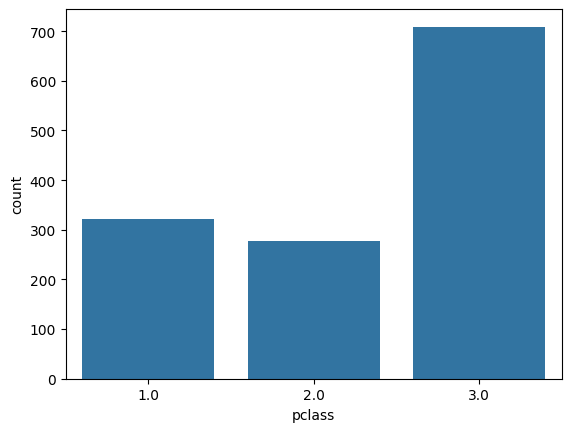

In [ ]:
sns.countplot(data=tnic, x=tnic["pclass"])

<Axes: xlabel='pclass', ylabel='count'>

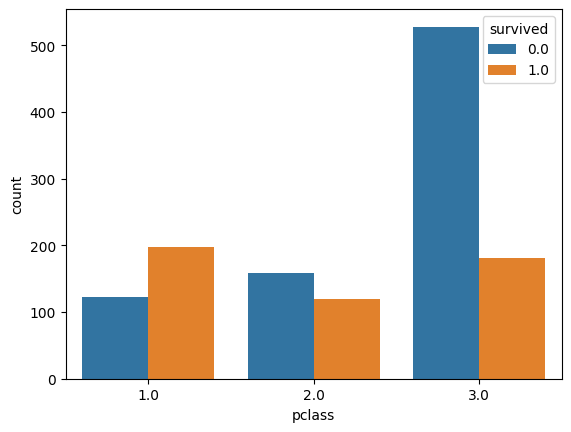

In [ ]:
sns.countplot(data=tnic, x='pclass', hue='survived')

In [ ]:
tnic.groupby('pclass')['survived'].value_counts(normalize=True).round(1).unstack()

survived,0.0,1.0
pclass,,
1.0,0.4,0.6
2.0,0.6,0.4
3.0,0.7,0.3


This ratio clearly says that the 3rd class passengers faced the most casaulties, though this projections says a story that's not in our data.

As, to undertand this ratio we must know that the 1st Class Cabins were in the top section of the Titanic Ship, and the 2nd Class in the middle, and lastly the 3rd Class Cabins were in the bottom of the ships, from front to end.

Thus when the Titanic struck the iceberg, the first ones to face the water were the Passengers from the Third Class.

A reference image is given below:

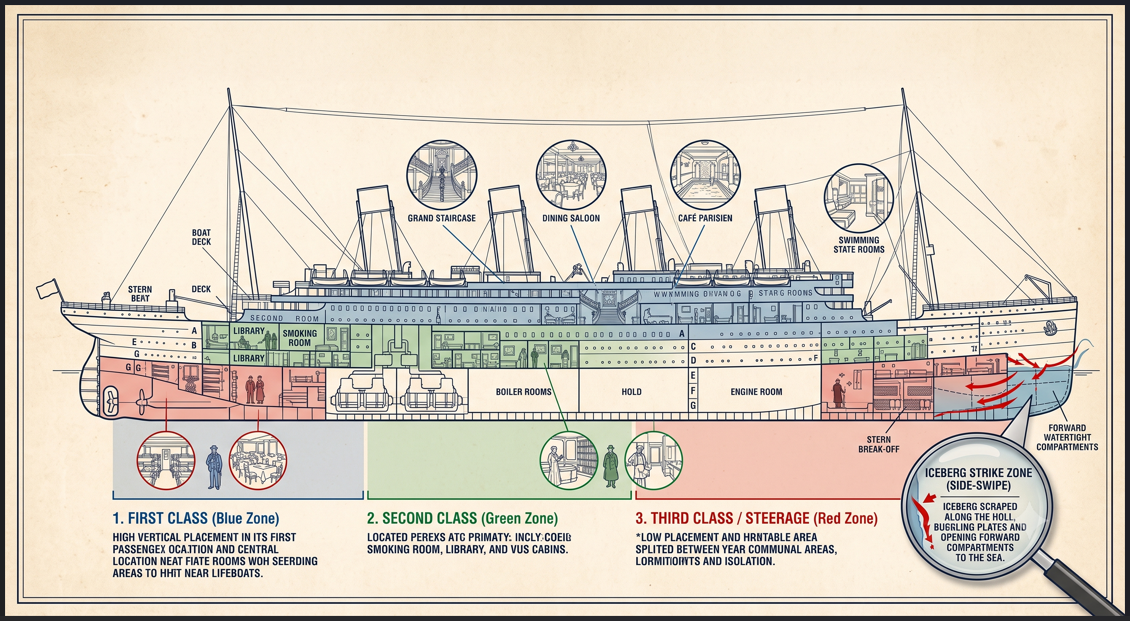


---

Now let's see how was the Survival when your **`age`** mattered.  

In [ ]:
bins = [0, 12, 19, 39, 59, tnic['age'].max()]
labels = ['Children (0-12)', 'Teens (13-19)', 'Young Adults (20-39)', 'Middle Aged (40-59)', 'Seniors (60+)']

tnic['age_group'] = pd.cut(tnic['age'], bins=bins, labels=labels, right=False)
tnic['age_group'].value_counts().sort_index()

,count
age_group,
Children (0-12),93
Teens (13-19),111
Young Adults (20-39),818
Middle Aged (40-59),243
Seniors (60+),41


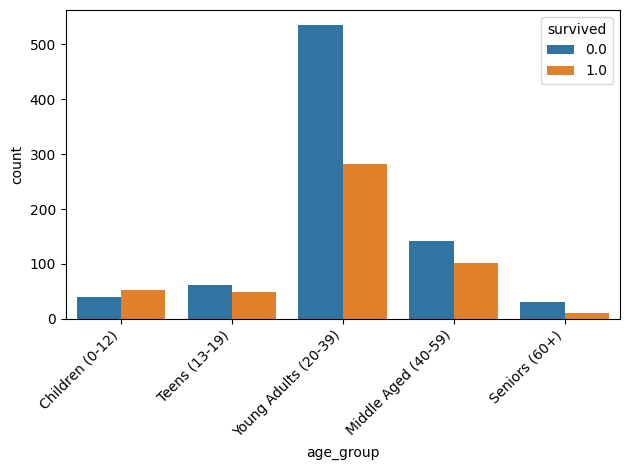

In [ ]:
sns.countplot(data=tnic, x=tnic["age_group"], hue=tnic["survived"])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [ ]:
age_group_counts = tnic['age_group'].value_counts().sort_index()
survival_by_age_group = tnic.groupby('age_group',  observed=False)['survived'].value_counts(normalize=True).round(1).unstack()

# Combine the survival rates with the total counts for each age group
combined_df = pd.concat([survival_by_age_group, age_group_counts.rename('Total Count')], axis=1)
combined_df

,0.0,1.0,Total Count
age_group,,,
Children (0-12),0.4,0.6,93
Teens (13-19),0.6,0.4,111
Young Adults (20-39),0.7,0.3,818
Middle Aged (40-59),0.6,0.4,243
Seniors (60+),0.7,0.3,41


Now let's visualize the survival projection for each age group, broken down by gender.

In [ ]:
df = pd.read_csv("data/titanic3.csv")
tnic = tnic.merge(df[["name", "sex"]], on="name", how="left")

Now we visualize:

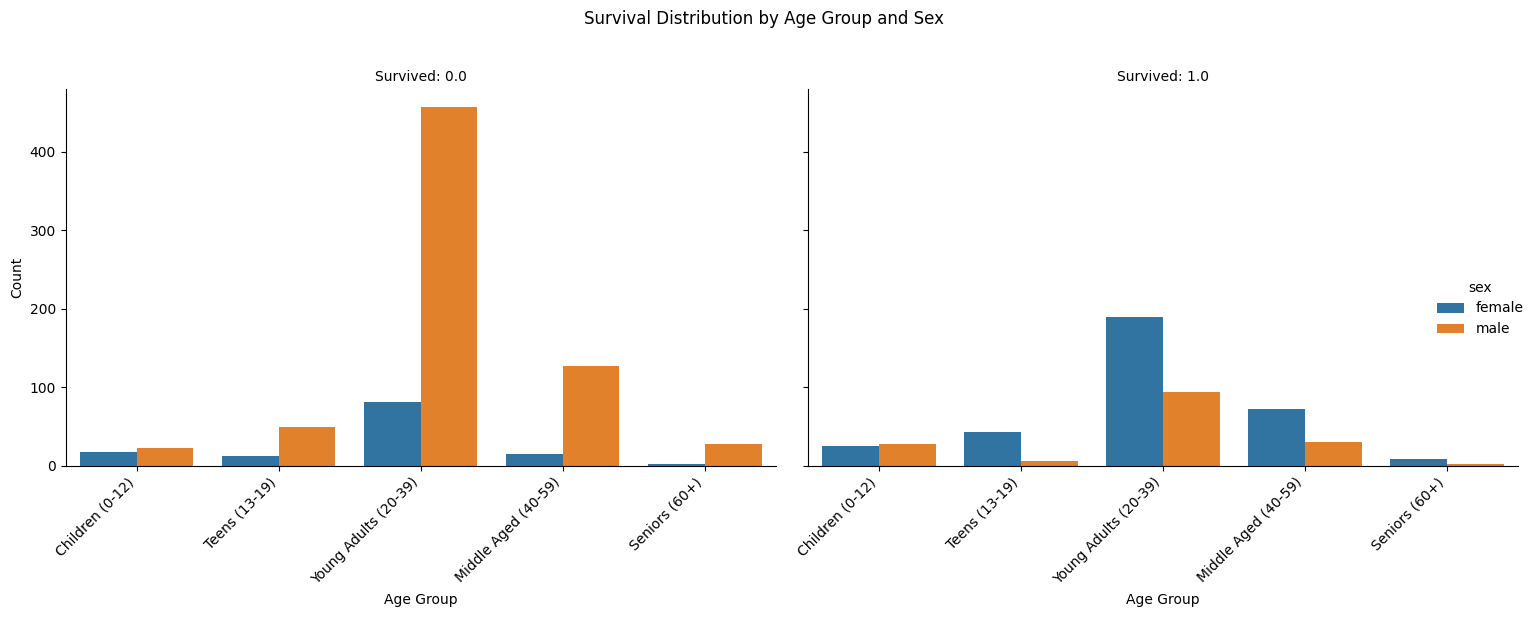

In [ ]:
g = sns.catplot(data=tnic, x='age_group', hue='sex', col='survived', kind='count', height=6, aspect=1.2)
g.set_axis_labels("Age Group", "Count")
g.set_titles("Survived: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Survival Distribution by Age Group and Sex', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()

The visualization confirms the historical protocol of prioritizing women and children during evacuation. While a portion of male passengers survived, the data reveals a stark class divide: the majority of surviving men belonged to the 1st and 2nd classes, underscoring how socioeconomic status heavily influenced access to the lifeboats.

---

The next thing we must do is learn about how was the condition of the passengers who had come with their families, such that we will utilize the `sibsp` (Siblings and Spouse) and `parch` (Parents and Children) features.

In [ ]:
tnic["sibsp"].value_counts().sort_index()

,count
sibsp,
0.0,893
1.0,319
2.0,42
3.0,20
4.0,22
5.0,6
8.0,9


In [ ]:
tnic["parch"].value_counts().sort_index()

,count
parch,
0.0,1004
1.0,170
2.0,113
3.0,8
4.0,6
5.0,6
6.0,2
9.0,2


Now to handle this with efficiency, we must seperate these groups in two. Those who came alone, and those who came with families.

First, let's check how many individuals were there.

In [ ]:
indis = tnic[(tnic['sibsp'] == 0.0) & (tnic['parch'] == 0.0)]
indis

,pclass,survived,age,sibsp,parch,ticket,fare,name,embarked,age_group,sex
0,1.0,1.0,29.0,0.0,0.0,24160,211.3375,"Allen, Miss. Elisabeth Walton",S,Young Adults (20-39),female
5,1.0,1.0,48.0,0.0,0.0,19952,26.5500,"Anderson, Mr. Harry",S,Middle Aged (40-59),male
7,1.0,0.0,39.0,0.0,0.0,112050,0.0000,"Andrews, Mr. Thomas Jr",S,Middle Aged (40-59),male
9,1.0,0.0,71.0,0.0,0.0,PC 17609,49.5042,"Artagaveytia, Mr. Ramon",C,Seniors (60+),male
12,1.0,1.0,24.0,0.0,0.0,PC 17477,69.3000,"Aubart, Mme. Leontine Pauline",C,Young Adults (20-39),female
...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,26.4,0.0,0.0,2647,7.2250,"Yousif, Mr. Wazli",C,Young Adults (20-39),male
1305,3.0,0.0,36.3,0.0,0.0,2627,14.4583,"Yousseff, Mr. Gerious",C,Young Adults (20-39),male
1308,3.0,0.0,26.5,0.0,0.0,2656,7.2250,"Zakarian, Mr. Mapriededer",C,Young Adults (20-39),male
1309,3.0,0.0,27.0,0.0,0.0,2670,7.2250,"Zakarian, Mr. Ortin",C,Young Adults (20-39),male


So there were **792** Individuals (`indis`).

  Let's make a columns to record them, Indivduals with respective label and fill the null values with label of "Family".

In [ ]:
tnic.loc[(tnic["sibsp"] == 0.0) & (tnic["parch"]== 0.0), "ptype"] = "Individual"

In [ ]:
tnic["ptype"] = tnic["ptype"].fillna("Family")

Now, we must visualise both the passenger types against `survived` feature.

<Axes: xlabel='ptype', ylabel='count'>

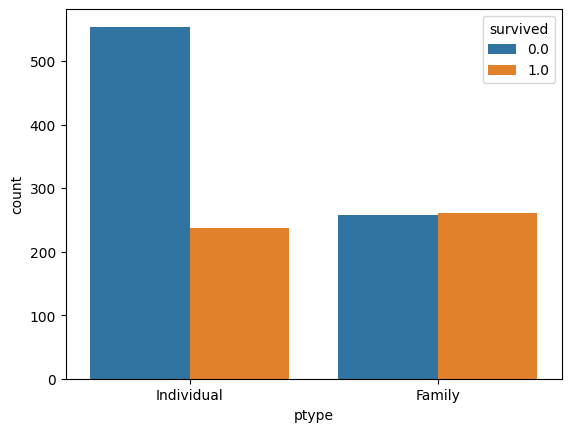

In [ ]:
sns.countplot(data=tnic, x=tnic["ptype"], hue=tnic["survived"])

Insights that can be extracted are:
1. Individuals faced most casualties.
2. Families somehow show almost the same number of survived and otherwise.
3. Though remember this, families include children too. And since at the time, it was high probablity that women did not travel alone on such trip, it is very possible that the Individul casaulty is mostly men.

To show the **Sex wise** casaulty in **Individual** passengers, here's a visualiation.

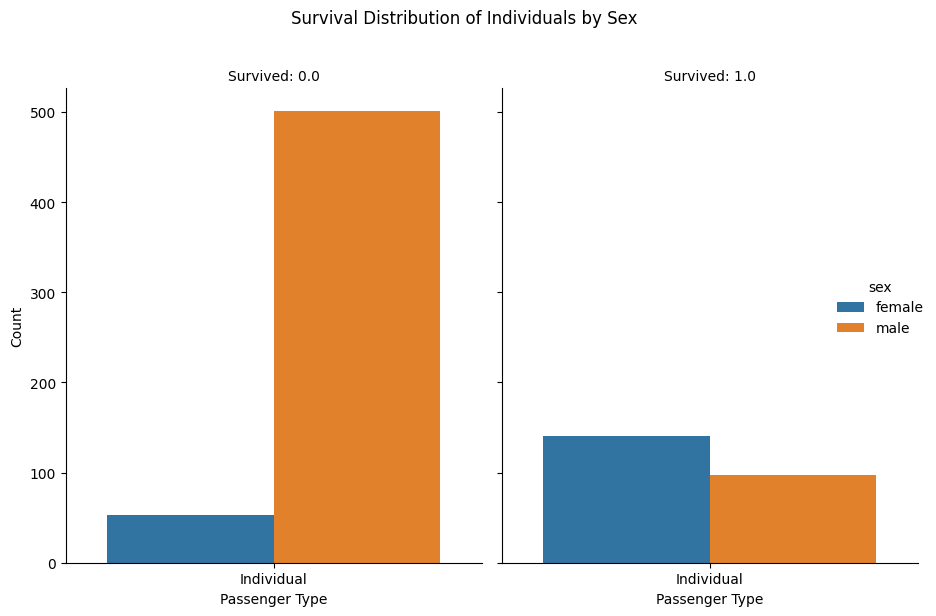

In [ ]:
k = sns.catplot(data=tnic[tnic['ptype'] == 'Individual'], x='ptype', hue='sex', col='survived', kind='count', height=6, aspect=0.7)
k.set_axis_labels("Passenger Type", "Count")
k.set_titles("Survived: {col_name}")
plt.suptitle('Survival Distribution of Individuals by Sex', y=1.02)
plt.tight_layout()
plt.show()

Now let's visualize the same for **Families**.

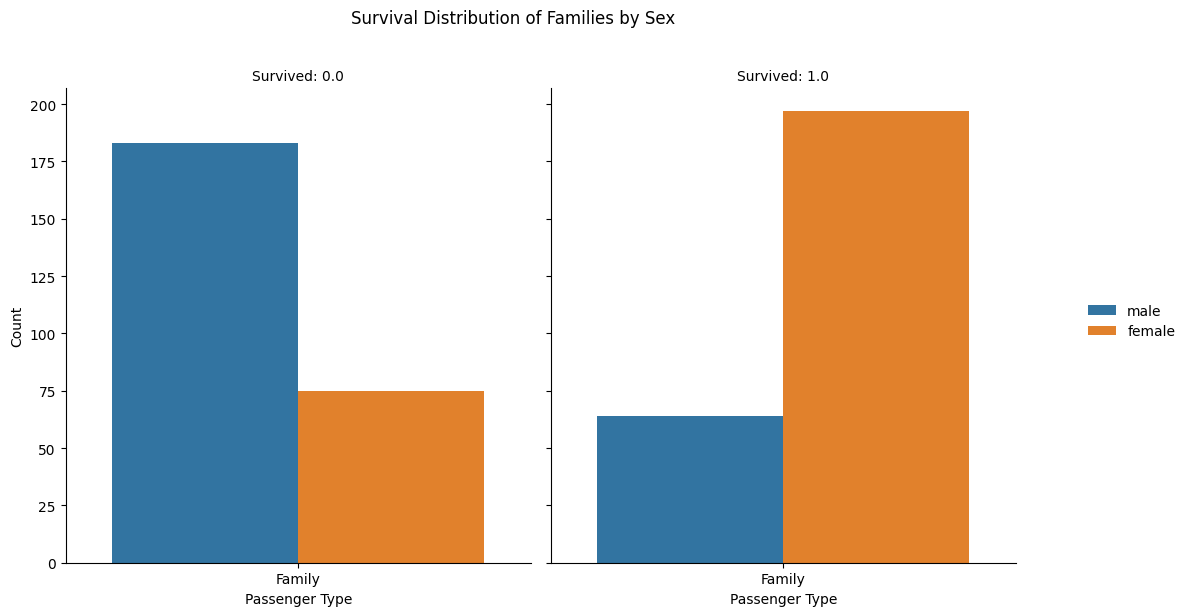

In [ ]:
f = sns.catplot(data=tnic[tnic['ptype'] == 'Family'], x='ptype', hue='sex', col='survived', kind='count', height=6, aspect=0.7)
f.set_axis_labels("Passenger Type", "Count")
f.set_titles("Survived: {col_name}")
plt.suptitle('Survival Distribution of Families by Sex', y=1.02)
f._legend.remove()
f.add_legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
plt.tight_layout()
plt.show()

Our insight was right. Very less women travelled individually, and Men faced most casaulty.

Now, we have covered `sibsp` and `parch` features with respect to subjectively related features making our insights powerful and obvious, further helping us in making the ML Model.

Now, we have one last feature to work on, which is `embarked`. There is not much to work here, but still for what we are gonna do, this remain a part of it.

Starting from visualization of it:

In [ ]:
tnic["embarked"].value_counts()

,count
embarked,
S,915
C,270
Q,126


Embarked column tells us from where did the recorded passengers boarded the ship, and these values represents boarding points as follows.

> S = Southampton (England)

> C = Cherbourg (France)

> Q = Queenstown (Ireland)




Let's visualize this against the `survived` feature.

<Axes: xlabel='embarked', ylabel='count'>

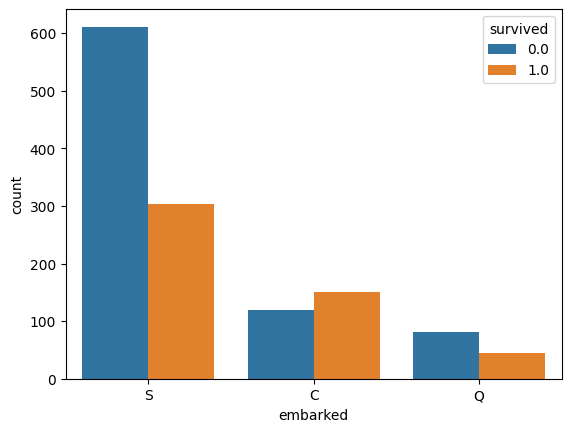

In [ ]:
sns.countplot(data=tnic, x=tnic["embarked"], hue=tnic["survived"])

Remember this though, these two features hardly corelate. There is little to no corelation, there might be if we go out of this data and scrape historical context.

This, shall be the end of our EDA.

## **Summary of Titanic Dataset EDA**

This Exploratory Data Analysis (EDA) of the Titanic dataset was conducted with the primary goal of extracting subjective and contextual data from various features. This understanding is intended to be used for the development of a choice-based game, focusing on the conditions, discriminations, and constraints faced during the Titanic sinking.

### **1. Setup and Data Overview**
-   **Libraries:** We began by importing essential libraries: `pandas` for data manipulation, `numpy` for numerical operations, `seaborn` for statistical data visualization, and `matplotlib.pyplot` for plotting.
-   **Dataset:** The `titanic3_cleaned.csv` dataset was uploaded and loaded into a DataFrame named `tnic`. Later, the original `titanic3.csv` was also uploaded and merged to retrieve the `sex` column, which was missing from the cleaned version.
-   **Features Discussed:** The core features for this analysis included `age`, `sex`, `pclass`, `sibsp` (siblings/spouse), `parch` (parents/children), `fare`, `cabin`, and `embarked`.

### **2. Feature Visualization and Analysis**

#### **a. `pclass` (Passenger Class)**
-   **Analysis:** We examined the distribution of passengers across the three classes (`1.0`, `2.0`, `3.0`) using `value_counts()` and `countplot`. We then visualized survival rates per class and calculated normalized survival probabilities.
-   **Insights:**
    -   The 3rd class had the highest number of passengers.
    -   A clear disparity in survival rates was observed: 1st class passengers had the highest survival rate (60%), followed by 2nd class (40%), and 3rd class (30%) had the lowest.
    -   This was contextually explained by the ship's layout, where 3rd class cabins were located in the lower sections, making them more vulnerable during the iceberg collision.

#### **b. `age` (Passenger Age)**
-   **Analysis:** To better understand age-related survival, we binned the `age` feature into five categories: `Children (0-12)`, `Teens (13-19)`, `Young Adults (20-39)`, `Middle Aged (40-59)`, and `Seniors (60+)`. We then visualized the distribution of these age groups and their survival rates using `countplot` and calculated normalized survival probabilities.
-   **Insights:**
    -   'Children (0-12)' had a higher survival rate (60%) compared to other age groups.
    -   'Teens', 'Young Adults', 'Middle Aged', and 'Seniors' generally showed lower survival rates (30-40%).

#### **c. `age` and `sex` (Combined Analysis)**
-   **Analysis:** We re-integrated the `sex` feature into our `tnic` DataFrame. A `catplot` was used to visualize the survival distribution across age groups, broken down by gender.
-   **Insights:**
    -   The visualization strongly confirmed the historical protocol of prioritizing women and children during evacuation.
    -   Female passengers across all age groups generally had significantly higher survival rates than male passengers.
    -   Even among surviving men, there appeared to be a class divide, with more men from 1st and 2nd classes surviving, though this was a qualitative observation from the visual.

#### **d. `sibsp` and `parch` (Family Status)**
-   **Analysis:** We analyzed `sibsp` and `parch` counts to determine family composition. A new feature, `ptype` (Passenger Type), was created to categorize passengers as either 'Individual' (traveling alone) or 'Family' (traveling with siblings/spouses or parents/children).
-   **Initial `ptype` Visualization:** A `countplot` showed that 'Individuals' faced more casualties than 'Families'.
-   **Sex-wise Breakdown for 'Individuals':** A `catplot` for 'Individual' passengers by sex and survival revealed that most individual casualties were men, indicating that very few women traveled alone.
-   **Sex-wise Breakdown for 'Families':** Another `catplot` for 'Family' passengers by sex and survival was generated. This visualization also addressed a legend overlap issue by repositioning it outside the plot area and removing duplicate legends.
-   **Insights:**
    -   Our initial insight was reinforced: the majority of individual casualties were men.
    -   For family passengers, significantly more women survived than men, further emphasizing the 'women and children first' protocol.

#### **e. `embarked` (Port of Embarkation)**
-   **Analysis:** We checked the `value_counts()` for the `embarked` column and provided a mapping for the codes: `S = Southampton`, `C = Cherbourg`, `Q = Queenstown`. A `countplot` was then used to visualize the embarkation points against survival.
-   **Insights:**
    -   The analysis showed the distribution of passengers from each port. However, based solely on this data, there was little to no direct correlation between the port of embarkation and survival rates. Any deeper correlation would likely require external historical context.

### **3. Conclusion**
This EDA journey has provided valuable insights into the various factors influencing survival on the Titanic, particularly `pclass`, `age`, `sex`, and family status. These findings are crucial for building a richer context for the choice-based game, highlighting the social dynamics and tragic circumstances of the event.